In [3]:
# %pip install -q seaborn

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns # type: ignore
import matplotlib.pyplot as plt
import warnings
from scipy.stats import pearsonr # type: ignore


warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")

def show_layout():
    plt.figure(figsize=(9, 4))
    plt.tight_layout()
    plt.show()

In [5]:
df = pd.read_csv( \
    r"C:\Users\AYO_AYO\Desktop\Machine-Learning-Bootcamp\CSV-Excel\Datasets\titanic_dataset.csv")

In [6]:
numerical_cols = df.select_dtypes([np.number]).columns.to_list()
categorical_cols = [col for col in df.columns if col not in numerical_cols]

print(numerical_cols)
print(categorical_cols)

['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [7]:
numerical_df = df[numerical_cols].dropna()
numerical_df.head()

,survived,pclass,age,sibsp,parch,fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500


In [8]:
numerical_df["survived_label"] = numerical_df["survived"].map({0:"No", 1:"Yes"})

#### **Boxplot Method**

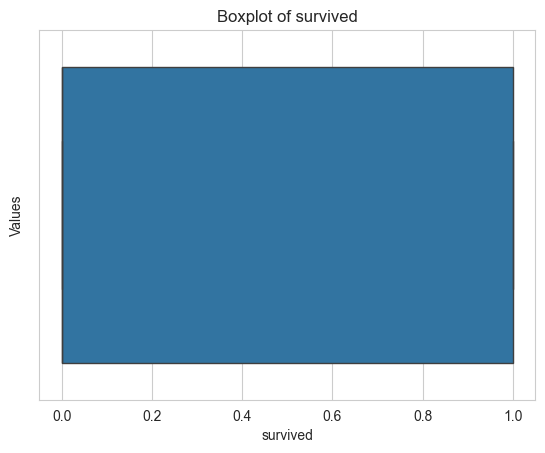

<Figure size 900x400 with 0 Axes>

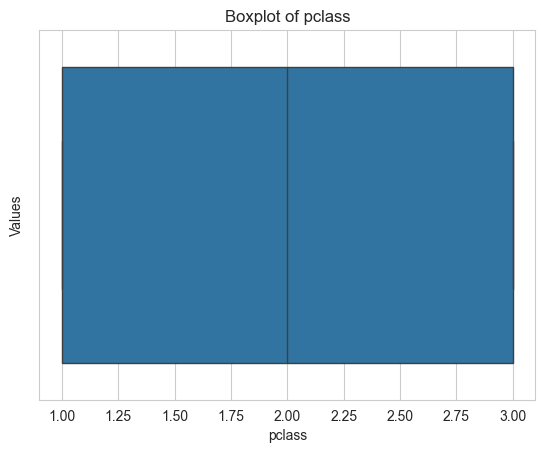

<Figure size 900x400 with 0 Axes>

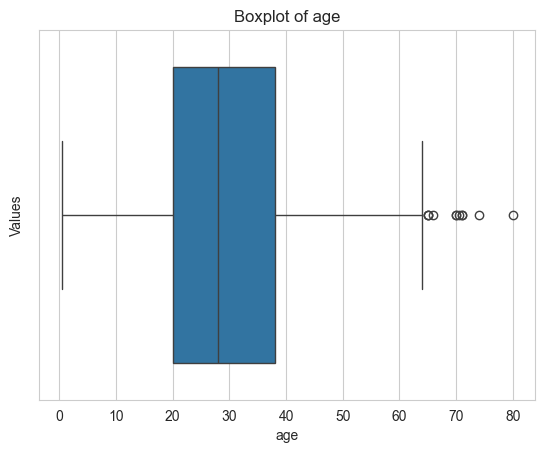

<Figure size 900x400 with 0 Axes>

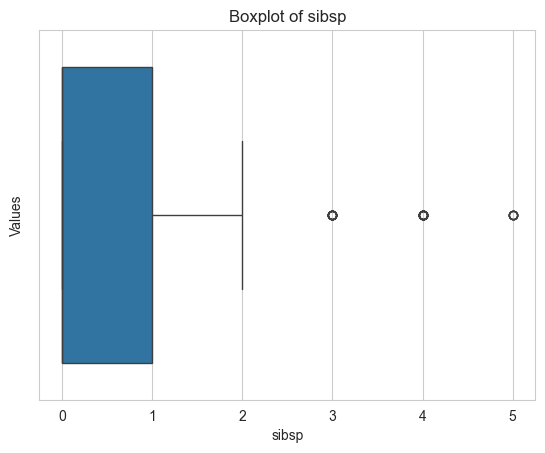

<Figure size 900x400 with 0 Axes>

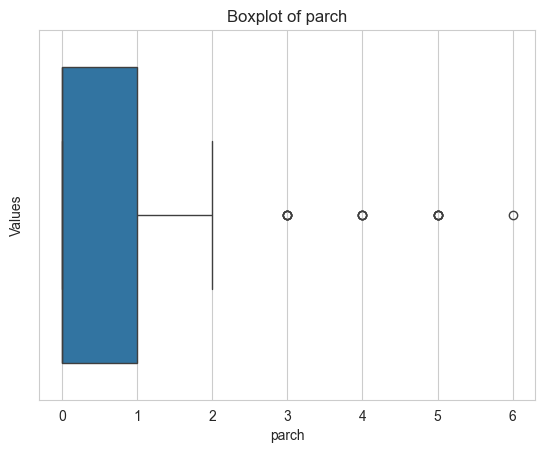

<Figure size 900x400 with 0 Axes>

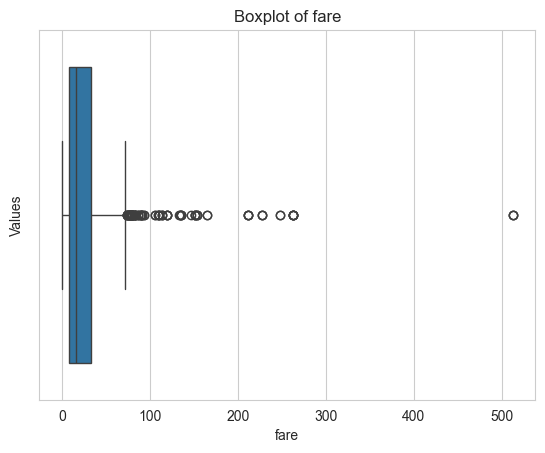

<Figure size 900x400 with 0 Axes>

In [9]:
for cols in numerical_cols:
    sns.boxplot(data=numerical_df, x=numerical_df[cols])
    plt.title(f"Boxplot of {cols}")
    plt.xlabel(cols)
    plt.ylabel("Values")
    show_layout()

#### **Using Z-Score Method**

In [10]:
upper_threshold = (round((numerical_df["fare"]) - (numerical_df["fare"].mean() + 3 * numerical_df["fare"].std()),2))
print("upper_threshold (greater than this value is an outlier/3)")
print(upper_threshold.head())

z_score = (numerical_df["fare"] - numerical_df["fare"].mean()) / numerical_df["fare"].std()
print("z_score without threshold")
print(z_score.head())

upper_threshold (greater than this value is an outlier/3)
0   -186.20
1   -122.17
2   -185.53
3   -140.35
4   -185.40
Name: fare, dtype: float64
z_score without threshold
0   -0.518614
1    0.691412
2   -0.505859
3    0.347805
4   -0.503497
Name: fare, dtype: float64


In [11]:
import scipy.stats as stats # type: ignore

z_score = stats.zscore(numerical_df["fare"])
for index, value in enumerate(z_score):
    if abs(value) > 3:
        print(f"Outlier at index {index} with z-score {value:.2f}")

Outlier at index 23 with z-score 4.32
Outlier at index 67 with z-score 4.32
Outlier at index 93 with z-score 4.02
Outlier at index 208 with z-score 9.03
Outlier at index 241 with z-score 4.02
Outlier at index 248 with z-score 4.31
Outlier at index 274 with z-score 4.32
Outlier at index 301 with z-score 3.34
Outlier at index 304 with z-score 3.65
Outlier at index 351 with z-score 4.32
Outlier at index 537 with z-score 9.03
Outlier at index 546 with z-score 3.34
Outlier at index 555 with z-score 3.65
Outlier at index 569 with z-score 3.65
Outlier at index 581 with z-score 3.34
Outlier at index 587 with z-score 9.03
Outlier at index 589 with z-score 4.31
Outlier at index 620 with z-score 3.34


In [ ]:
z_threshold = 3.0

for cols in numerical_cols:
    clean_cols = df[cols].dropna()
    mean = clean_cols.mean()
    std = clean_cols.std()

    z_scores = (clean_cols - mean) / std
    outlier_mask = np.abs(z_scores) > z_threshold
    num_of_outliers = outlier_mask.sum()
    total = clean_cols[0]
    print(f"Z Score :{""}, Outlier: {outlier_mask}")

#### **IQR Method**

In [12]:
def iqr_bound(series, factor = 1.5):
    Q1 = series.quantile(.25)
    Q3 = series.quantile(.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR
    return lower_bound, upper_bound, IQR

In [13]:
numerical_cols

['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']

In [14]:
for cols in numerical_cols:
    clean_cols = df[cols].dropna()
    lower, upper, iqr = iqr_bound(clean_cols)
    outlier_mask = ((clean_cols < lower) | (clean_cols > upper))
    num_of_outliers = outlier_mask.sum()
    total = clean_cols.shape

    print(f"IQR Method For {cols}")    
    print(f"Q1 - 1.5 * IQR {lower:.2f}")    
    print(f"Q3 + 1.5 * IQR {upper:.2f}")    
    print(f"IQR: {iqr:.2f}")
    print(f"Outlier: {num_of_outliers}, out of {total[0]}")
    print()

IQR Method For survived
Q1 - 1.5 * IQR -1.50
Q3 + 1.5 * IQR 2.50
IQR: 1.00
Outlier: 0, out of 891

IQR Method For pclass
Q1 - 1.5 * IQR 0.50
Q3 + 1.5 * IQR 4.50
IQR: 1.00
Outlier: 0, out of 891

IQR Method For age
Q1 - 1.5 * IQR -6.69
Q3 + 1.5 * IQR 64.81
IQR: 17.88
Outlier: 11, out of 714

IQR Method For sibsp
Q1 - 1.5 * IQR -1.50
Q3 + 1.5 * IQR 2.50
IQR: 1.00
Outlier: 46, out of 891

IQR Method For parch
Q1 - 1.5 * IQR 0.00
Q3 + 1.5 * IQR 0.00
IQR: 0.00
Outlier: 213, out of 891

IQR Method For fare
Q1 - 1.5 * IQR -26.72
Q3 + 1.5 * IQR 65.63
IQR: 23.09
Outlier: 116, out of 891



Z Score :0     -0.788829
1      1.266279
2      1.266279
3      1.266279
4     -0.788829
         ...   
886   -0.788829
887    1.266279
888   -0.788829
889    1.266279
890   -0.788829
Name: survived, Length: 891, dtype: float64, Outlier: 0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Name: survived, Length: 891, dtype: bool
Z Score :0      0.826913
1     -1.565228
2      0.826913
3     -1.565228
4      0.826913
         ...   
886   -0.369158
887   -1.565228
888    0.826913
889   -1.565228
890    0.826913
Name: pclass, Length: 891, dtype: float64, Outlier: 0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Name: pclass, Length: 891, dtype: bool
Z Score :0     -0.530005
1      0.571430
2     -0.254646
3      0.364911
4      0.364911
         ...   
885    0.640270
886   -0.185807
887   -0.736524
889  